Dataset shape: (40, 2)
                                text sentiment
0     I absolutely love this product  Positive
1            This product is amazing  Positive
2          The service was excellent  Positive
3  I am very happy with the purchase  Positive
4           The quality is fantastic  Positive

Training samples: 30
Testing samples: 10

TF-IDF Training Shape: (30, 81)
TF-IDF Testing Shape: (10, 81)

MODEL PERFORMANCE
Accuracy: 50.0 %

Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      0.60      0.55         5
    Positive       0.50      0.40      0.44         5

    accuracy                           0.50        10
   macro avg       0.50      0.50      0.49        10
weighted avg       0.50      0.50      0.49        10



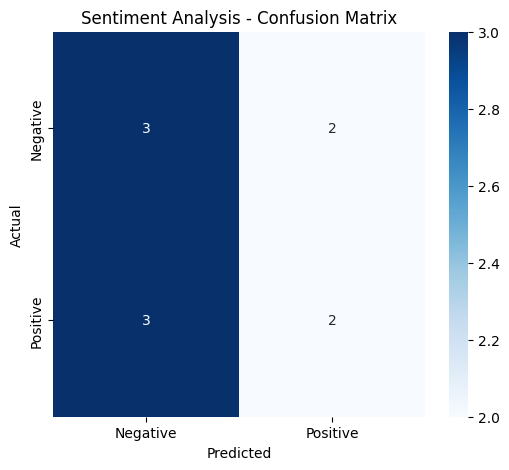


Test Predictions:
                                   Text Actual_Sentiment Predicted_Sentiment  \
0             The product does not work         Negative            Negative   
1  Terrible experience and poor quality         Negative            Negative   
2       I am satisfied with the service         Positive            Negative   
3                 The delivery was late         Negative            Positive   
4           Very useful and easy to use         Positive            Negative   
5         The product failed completely         Negative            Negative   
6     I would definitely recommend this         Positive            Negative   
7        I absolutely love this product         Positive            Positive   
8               This product is amazing         Positive            Positive   
9             Very bad customer service         Negative            Positive   

   Positive_Probability  Negative_Probability  
0              0.476840              0.523160  
1   

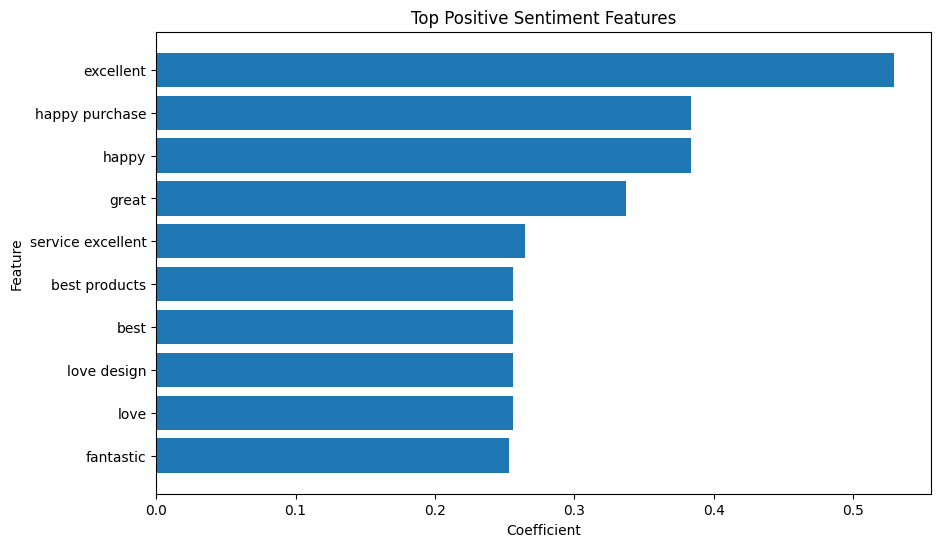

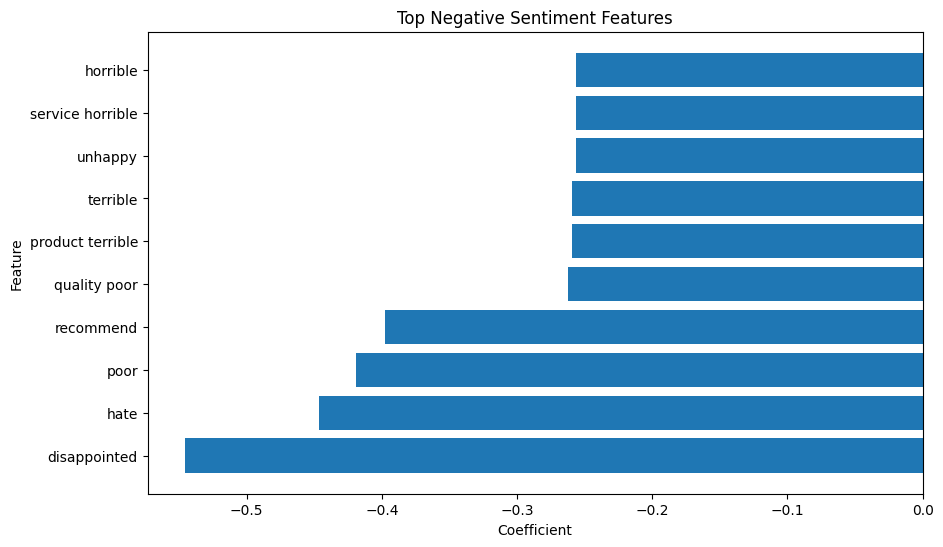


FILES SAVED SUCCESSFULLY
sentiment_predictions.csv
sentiment_custom_predictions.csv
sentiment_feature_importance.csv
sentiment_model_summary.csv

Day 14 completed successfully!


In [1]:
# ============================================
# DAY 14 - SENTIMENT ANALYSIS
# Logistic Regression + TF-IDF
# ============================================

# Install required libraries if needed
!pip install scikit-learn pandas matplotlib seaborn -q

# ============================================
# 1. Import Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ============================================
# 2. Create Dataset
# ============================================

data = {
    "text": [
        "I absolutely love this product",
        "This product is amazing",
        "The service was excellent",
        "I am very happy with the purchase",
        "The quality is fantastic",
        "I really enjoyed this experience",
        "The product works perfectly",
        "Very good customer service",
        "I would definitely recommend this",
        "This is one of the best products",
        "Amazing experience and great quality",
        "I am satisfied with the service",
        "The delivery was fast and excellent",
        "Really happy with my purchase",
        "The product exceeded my expectations",
        "Excellent support from the team",
        "I love the design",
        "Very useful and easy to use",
        "Great experience overall",
        "This product is worth the money",

        "I hate this product",
        "This product is terrible",
        "The service was horrible",
        "I am very disappointed",
        "The quality is very poor",
        "I did not like this experience",
        "The product does not work",
        "Very bad customer service",
        "I would not recommend this",
        "This is one of the worst products",
        "Terrible experience and poor quality",
        "I am unhappy with the service",
        "The delivery was late",
        "Really disappointed with my purchase",
        "The product failed completely",
        "Poor support from the team",
        "I hate the design",
        "Very difficult to use",
        "Bad experience overall",
        "This product is not worth the money"
    ],

    "sentiment": [
        "Positive", "Positive", "Positive", "Positive", "Positive",
        "Positive", "Positive", "Positive", "Positive", "Positive",
        "Positive", "Positive", "Positive", "Positive", "Positive",
        "Positive", "Positive", "Positive", "Positive", "Positive",

        "Negative", "Negative", "Negative", "Negative", "Negative",
        "Negative", "Negative", "Negative", "Negative", "Negative",
        "Negative", "Negative", "Negative", "Negative", "Negative",
        "Negative", "Negative", "Negative", "Negative", "Negative"
    ]
}

df = pd.DataFrame(data)

print("Dataset shape:", df.shape)
print(df.head())

# ============================================
# 3. Convert Labels
# Positive = 1
# Negative = 0
# ============================================

df["label"] = df["sentiment"].map({
    "Negative": 0,
    "Positive": 1
})

X = df["text"]
y = df["label"]

# ============================================
# 4. Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# ============================================
# 5. TF-IDF Vectorization
# ============================================

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=1000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("\nTF-IDF Training Shape:", X_train_tfidf.shape)
print("TF-IDF Testing Shape:", X_test_tfidf.shape)

# ============================================
# 6. Train Logistic Regression
# ============================================

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

# ============================================
# 7. Predictions
# ============================================

y_pred = model.predict(X_test_tfidf)
y_probability = model.predict_proba(X_test_tfidf)

# ============================================
# 8. Accuracy
# ============================================

accuracy = accuracy_score(y_test, y_pred)

print("\n================================")
print("MODEL PERFORMANCE")
print("================================")
print("Accuracy:", round(accuracy * 100, 2), "%")

# ============================================
# 9. Classification Report
# ============================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

# ============================================
# 10. Confusion Matrix
# ============================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Sentiment Analysis - Confusion Matrix")
plt.show()

# ============================================
# 11. Test Predictions DataFrame
# ============================================

prediction_df = pd.DataFrame({
    "Text": X_test.values,
    "Actual_Sentiment": np.where(
        y_test.values == 1,
        "Positive",
        "Negative"
    ),
    "Predicted_Sentiment": np.where(
        y_pred == 1,
        "Positive",
        "Negative"
    ),
    "Positive_Probability": y_probability[:, 1],
    "Negative_Probability": y_probability[:, 0]
})

print("\nTest Predictions:")
print(prediction_df)

# ============================================
# 12. Custom Sentiment Prediction
# ============================================

custom_messages = [
    "I really love this product",
    "The service was very bad",
    "Amazing quality and excellent experience",
    "I am disappointed with this purchase",
    "This product is fantastic"
]

custom_tfidf = vectorizer.transform(custom_messages)

custom_predictions = model.predict(custom_tfidf)
custom_probabilities = model.predict_proba(custom_tfidf)

custom_df = pd.DataFrame({
    "Text": custom_messages,
    "Predicted_Sentiment": np.where(
        custom_predictions == 1,
        "Positive",
        "Negative"
    ),
    "Positive_Probability": custom_probabilities[:, 1],
    "Negative_Probability": custom_probabilities[:, 0]
})

print("\nCustom Predictions:")
print(custom_df)

# ============================================
# 13. Feature Importance
# ============================================

feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Sentiment"] = np.where(
    feature_importance["Coefficient"] > 0,
    "Positive",
    "Negative"
)

feature_importance = feature_importance.sort_values(
    "Coefficient",
    ascending=False
)

print("\nTop Positive Words:")
print(feature_importance.head(10))

print("\nTop Negative Words:")
print(feature_importance.tail(10))

# ============================================
# 14. Visualize Important Features
# ============================================

top_positive = feature_importance.head(10)

top_negative = feature_importance.tail(10).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_positive["Feature"],
    top_positive["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Positive Sentiment Features")
plt.gca().invert_yaxis()

plt.show()

plt.figure(figsize=(10, 6))

plt.barh(
    top_negative["Feature"],
    top_negative["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Negative Sentiment Features")

plt.show()

# ============================================
# 15. Save Results
# ============================================

prediction_df.to_csv(
    "sentiment_predictions.csv",
    index=False
)

custom_df.to_csv(
    "sentiment_custom_predictions.csv",
    index=False
)

feature_importance.to_csv(
    "sentiment_feature_importance.csv",
    index=False
)

model_summary = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Vectorizer": ["TF-IDF"],
    "Training_Samples": [len(X_train)],
    "Testing_Samples": [len(X_test)],
    "Accuracy": [accuracy],
    "Features": [len(feature_names)]
})

model_summary.to_csv(
    "sentiment_model_summary.csv",
    index=False
)

print("\n================================")
print("FILES SAVED SUCCESSFULLY")
print("================================")

print("sentiment_predictions.csv")
print("sentiment_custom_predictions.csv")
print("sentiment_feature_importance.csv")
print("sentiment_model_summary.csv")

print("\nDay 14 completed successfully!")
